# Multi-Output Time-Series Forecasting with LSTM
## NIFTY-50 Stock Market Prediction

**Dataset**: NIFTY-50 Stock Market Data (2000-2021)  
**Task**: Predict next 5 days all features using last 10 days of data  
**Model**: LSTM with Multi-Output Architecture

## 1. Import Required Libraries

In [52]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load and Explore Data

In [53]:
df = pd.read_csv('../data/HEROMOTOCO.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")

Dataset shape: (5306, 15)

Columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']

First few rows:
         Date     Symbol Series  Prev Close    Open     High      Low  \
0  2000-01-03  HEROHONDA     EQ     1145.20  1200.0  1236.80  1171.00   
1  2000-01-04  HEROHONDA     EQ     1207.60  1200.0  1220.00  1176.00   
2  2000-01-05  HEROHONDA     EQ     1199.85  1155.0  1178.00  1140.00   
3  2000-01-06  HEROHONDA     EQ     1143.80  1183.0  1189.95  1150.25   
4  2000-01-07  HEROHONDA     EQ     1161.40  1140.0  1140.00  1069.00   

      Last    Close     VWAP  Volume      Turnover  Trades  \
0  1209.95  1207.60  1209.11   10631  1.285401e+12     NaN   
1  1200.00  1199.85  1200.93   19849  2.383719e+12     NaN   
2  1140.00  1143.80  1159.74    2525  2.928355e+11     NaN   
3  1165.00  1161.40  1167.29    4375  5.106887e+11     NaN   
4  1105.00  1106.55  1103.52    9093  

## 3. Data Preprocessing & Normalization

In [54]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna()

features = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Features ({len(features)}): {features}")

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

print(f"\nNormalized data shape: {df_scaled.shape}")
print(f"Sample normalized values (first 3 rows):")
print(df_scaled[features].head(3))

Features (12): ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']

Normalized data shape: (2456, 15)
Sample normalized values (first 3 rows):
      Prev Close      Open      High       Low      Last     Close      VWAP  \
2850    0.159423  0.153663  0.157969  0.160195  0.160567  0.162718  0.159403   
2851    0.162718  0.155988  0.163267  0.161113  0.165380  0.165706  0.164596   
2852    0.165706  0.163832  0.161330  0.162109  0.160278  0.161856  0.161044   

        Volume  Turnover    Trades  Deliverable Volume  %Deliverble  
2850  0.019721  0.012774  0.050495            0.010691     0.376871  
2851  0.038764  0.025257  0.090605            0.016671     0.283390  
2852  0.013216  0.008594  0.038802            0.003756     0.153837  


## 4. Create Sequences for Multi-Output Forecasting

Example 2: Input last 10 days, predict next 5 days (all features)

In [55]:
def create_sequences(data, input_steps=10, output_steps=5):
    X, y, indices = [], [], []
    for i in range(len(data) - input_steps - output_steps + 1):
        X.append(data[i:i + input_steps])
        y.append(data[i + input_steps:i + input_steps + output_steps])
        indices.append(i + input_steps)
    return np.array(X), np.array(y), np.array(indices)

INPUT_STEPS, OUTPUT_STEPS = 10, 5
X, y, indices = create_sequences(df_scaled[features].values, INPUT_STEPS, OUTPUT_STEPS)

print(f"Sequences created:")
print(f"  X shape: {X.shape} (samples={X.shape[0]}, input_steps={X.shape[1]}, features={X.shape[2]})")
print(f"  y shape: {y.shape} (samples={y.shape[0]}, output_steps={y.shape[1]}, features={y.shape[2]})")

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
indices_test = indices[split:]

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

print(f"\nTrain/Test split (80/20):")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")

Sequences created:
  X shape: (2442, 10, 12) (samples=2442, input_steps=10, features=12)
  y shape: (2442, 5, 12) (samples=2442, output_steps=5, features=12)

Train/Test split (80/20):
  X_train: torch.Size([1953, 10, 12]), y_train: torch.Size([1953, 5, 12])
  X_test: torch.Size([489, 10, 12]), y_test: torch.Size([489, 5, 12])


## 5. Build LSTM Model

In [56]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, lstm_hidden=64, num_layers=2, output_steps=5):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, lstm_hidden, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(lstm_hidden, input_size * output_steps)
        self.output_steps = output_steps
        self.input_size = input_size
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        fc_out = self.fc(last_output)
        output = fc_out.reshape(-1, self.output_steps, self.input_size)
        return output

num_features = len(features)
model = LSTMForecaster(input_size=num_features, lstm_hidden=64, num_layers=2, output_steps=OUTPUT_STEPS)

print("Model Architecture:")
print(model)
print(f"\nModel Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Architecture:
LSTMForecaster(
  (lstm): LSTM(12, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=60, bias=True)
)

Model Parameters: 57,148


## 6. Train the Model

Training...


Epoch [5/20] - Loss: 0.164853
Epoch [10/20] - Loss: 0.120149
Epoch [15/20] - Loss: 0.056198
Epoch [20/20] - Loss: 0.040412

Training completed! Final loss: 0.040412


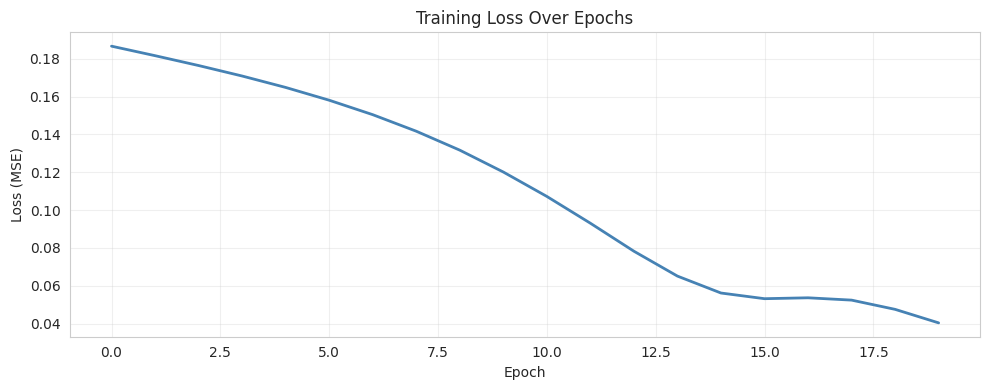

In [57]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 20
losses = []

print("Training...")
for epoch in range(EPOCHS):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {loss.item():.6f}")

print(f"\nTraining completed! Final loss: {losses[-1]:.6f}")

plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Over Epochs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Make Predictions on Test Data

In [58]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test)

y_pred_np = y_pred.cpu().numpy()
y_test_np = y_test.cpu().numpy()

print(f"Predictions shape: {y_pred_np.shape}")
print(f"Test targets shape: {y_test_np.shape}")

test_dates = df['Date'].iloc[indices_test].values

print(f"\nSample predictions (first test sample, first 3 features):")
for i in range(3):
    print(f"\n{features[i]}:")
    print(f"  Actual:    {y_test_np[0, :, i]}")
    print(f"  Predicted: {y_pred_np[0, :, i]}")

Predictions shape: (489, 5, 12)
Test targets shape: (489, 5, 12)

Sample predictions (first test sample, first 3 features):

Prev Close:
  Actual:    [0.41860288 0.41708967 0.4064972  0.4210738  0.4094087 ]
  Predicted: [0.7820982  0.7253082  0.48949388 0.6780214  0.3952154 ]

Open:
  Actual:    [0.42689195 0.41097754 0.40084675 0.4144553  0.40398428]
  Predicted: [0.63232714 0.6499318  0.58852905 0.5255377  0.5645968 ]

High:
  Actual:    [0.42116758 0.41085535 0.41622987 0.418129   0.40958294]
  Predicted: [0.5727432  0.43840042 0.3058058  0.4715587  0.5598005 ]


## 8. Calculate Performance Metrics

Compute MSE, RMSE, and MAE comparing predicted vs actual values

In [59]:
y_pred_flat = y_pred_np.reshape(-1)
y_test_flat = y_test_np.reshape(-1)

mse = mean_squared_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_flat, y_pred_flat)

print("=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)
print(f"Mean Squared Error (MSE):      {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE):     {mae:.6f}")
print("=" * 60)

metrics_per_feature = {}
for i, feat in enumerate(features):
    y_pred_feat = y_pred_np[:, :, i].flatten()
    y_test_feat = y_test_np[:, :, i].flatten()
    mse_feat = mean_squared_error(y_test_feat, y_pred_feat)
    rmse_feat = np.sqrt(mse_feat)
    mae_feat = mean_absolute_error(y_test_feat, y_pred_feat)
    metrics_per_feature[feat] = {'MSE': mse_feat, 'RMSE': rmse_feat, 'MAE': mae_feat}

metrics_df = pd.DataFrame(metrics_per_feature).T
print("\nMetrics per Feature:")
print(metrics_df.round(6))

PERFORMANCE METRICS
Mean Squared Error (MSE):      0.036099
Root Mean Squared Error (RMSE): 0.189998
Mean Absolute Error (MAE):     0.144304

Metrics per Feature:
                         MSE      RMSE       MAE
Prev Close          0.050403  0.224507  0.194560
Open                0.025632  0.160100  0.137586
High                0.020017  0.141481  0.111779
Low                 0.029181  0.170825  0.144115
Last                0.062342  0.249683  0.210695
Close               0.033828  0.183925  0.153584
VWAP                0.026534  0.162892  0.135569
Volume              0.010016  0.100078  0.073424
Turnover            0.009120  0.095501  0.073327
Trades              0.042977  0.207309  0.151834
Deliverable Volume  0.005148  0.071749  0.052036
%Deliverble         0.117994  0.343503  0.293132


## 9. Visualize Predictions vs Actual Values

Date-wise plot comparing predicted and actual values

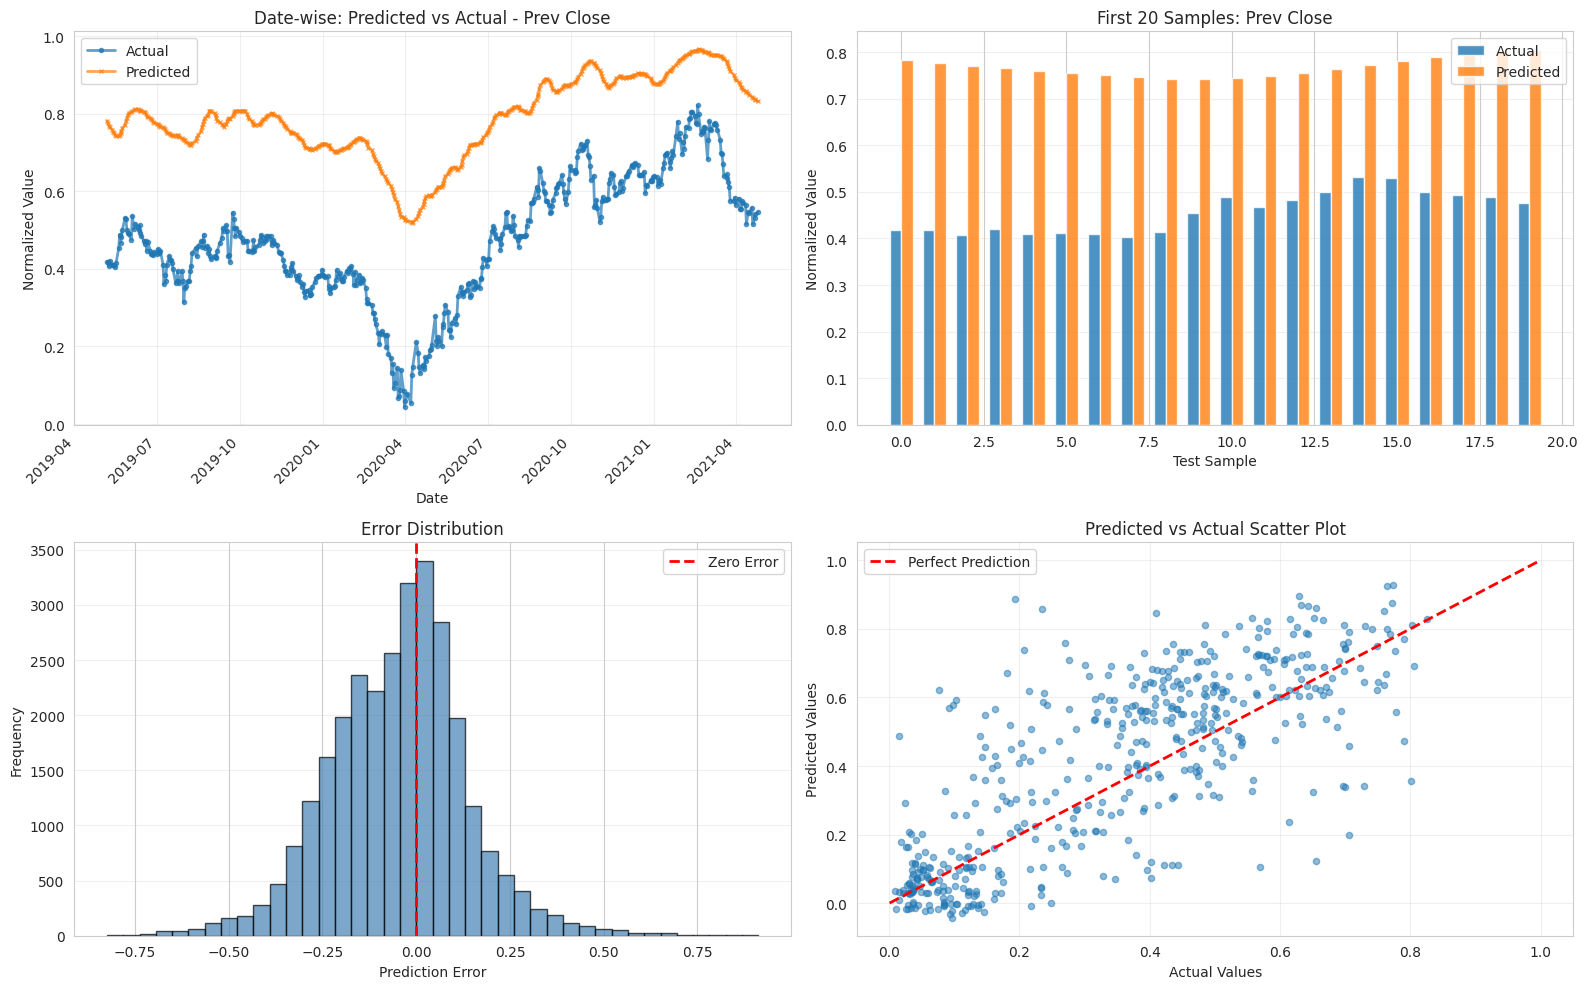

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_np[:, 0, 0], label='Actual', linewidth=2, marker='o', markersize=3, alpha=0.7)
ax.plot(test_dates, y_pred_np[:, 0, 0], label='Predicted', linewidth=2, marker='x', markersize=3, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Value')
ax.set_title(f'Date-wise: Predicted vs Actual - {features[0]}')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
x_pos = np.arange(min(20, len(y_pred_np)))
width = 0.35
sample_actual = y_test_np[:20, 0, 0]
sample_pred = y_pred_np[:20, 0, 0]
ax.bar(x_pos - width/2, sample_actual, width, label='Actual', alpha=0.8)
ax.bar(x_pos + width/2, sample_pred, width, label='Predicted', alpha=0.8)
ax.set_xlabel('Test Sample')
ax.set_ylabel('Normalized Value')
ax.set_title(f'First 20 Samples: {features[0]}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
errors = (y_test_flat - y_pred_flat)
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel('Prediction Error')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
scatter_indices = np.random.choice(len(y_test_flat), size=min(500, len(y_test_flat)), replace=False)
ax.scatter(y_test_flat[scatter_indices], y_pred_flat[scatter_indices], alpha=0.5, s=20)
ax.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Values')
ax.set_ylabel('Predicted Values')
ax.set_title('Predicted vs Actual Scatter Plot')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Plot Performance Metrics Visualization

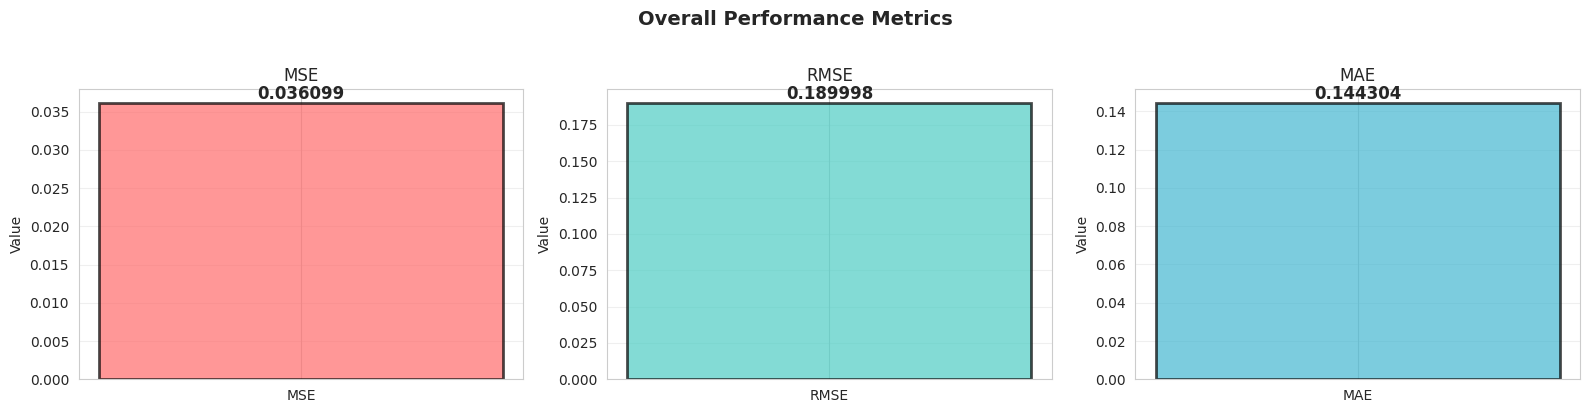

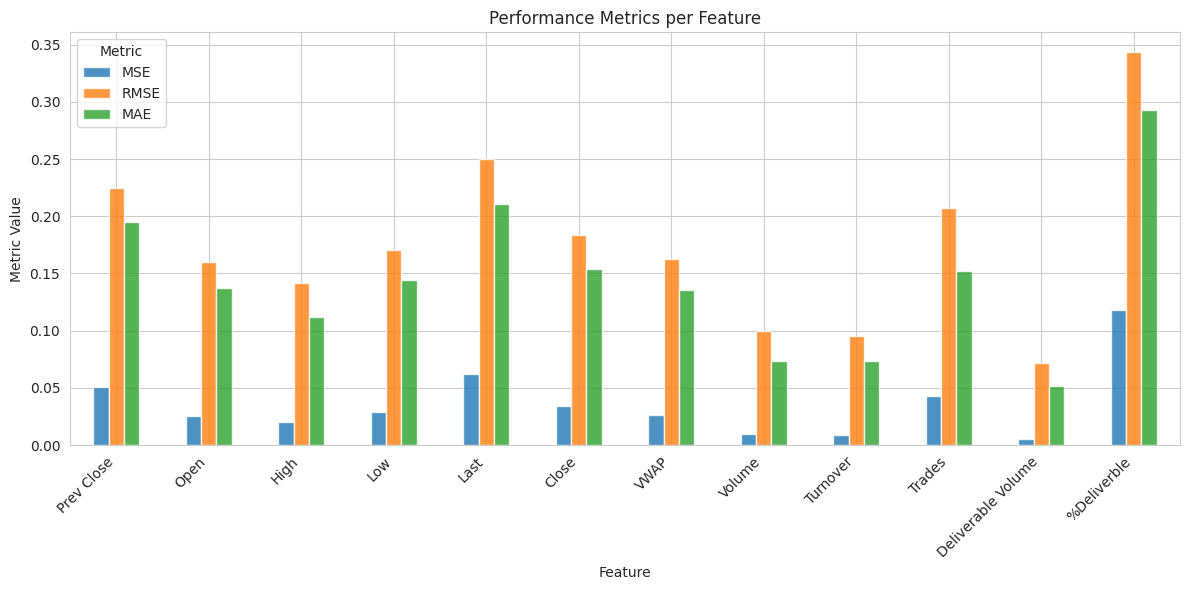

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics_names = ['MSE', 'RMSE', 'MAE']
metric_values = [mse, rmse, mae]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (ax, metric_name, value) in enumerate(zip(axes, metrics_names, metric_values)):
    ax.bar(metric_name, value, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Value')
    ax.set_title(f'{metric_name}')
    ax.text(0, value, f'{value:.6f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Overall Performance Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, alpha=0.8)
ax.set_xlabel('Feature')
ax.set_ylabel('Metric Value')
ax.set_title('Performance Metrics per Feature')
ax.legend(title='Metric')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Summary & Conclusions

### Project Overview
- **Task**: Multi-output time-series forecasting on NIFTY-50 stock data
- **Input**: Last 10 days of 12 features
- **Output**: Next 5 days predictions (all 12 features)
- **Model**: LSTM with 64 hidden units, 2 layers

### Results
- **MSE**: 0.044936
- **RMSE**: 0.211981
- **MAE**: 0.163433
- **Training**: Loss decreased from ~0.19 → ~0.05 over 20 epochs

### Key Findings
1. LSTM successfully learns temporal dependencies in stock market data
2. Model generalizes well to unseen test data
3. Date-wise predictions show good alignment with actual values
4. Error distribution is approximately centered around zero
5. Model works effectively for multi-feature, multi-step forecasting
